In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage
import pandas as pd
import os
import glob
import math
import random
import matplotlib.pyplot as plt
csv_filename = "Results/V3.csv"

In [3]:
df = pd.read_csv(csv_filename)
print(df.head())

  Imagen_idobject  Scene_coordinate_system  Area_px  Area_mm2  Perimetro_px  \
0         xy003_0                      0.0     1263  0.591155    147.112698   
1         xy003_1                      0.0     1080  0.505501    128.769552   
2         xy003_2                      0.0     4396  2.057577    279.982755   
3         xy003_3                      0.0     2923  1.368129    259.012193   
4         xy003_4                      0.0     1425  0.666981    162.124890   

   Perimetro_mm  Diametro_px  Diametro_mm  Escala_mm_por_px  \
0      3.182727    40.101141     0.867573          0.021635   
1      2.785880    37.082323     0.802262          0.021635   
2      6.057319    74.814177     1.618576          0.021635   
3      5.603629    61.005567     1.319832          0.021635   
4      3.507510    42.595379     0.921535          0.021635   

   Porcentaje_no_pintado   Coordenades  Class_id  aspect_ratio  
0              47.057477   [[90, 498]]         8      0.673469  
1              4

In [10]:
df['Imagen_idobject_substr'] = df['Imagen_idobject'].str[2:5]
df['Imagen_idobject_substr'] = df['Imagen_idobject_substr'].str.replace('_', '')
df['Imagen_idobject_substr'] = df['Imagen_idobject_substr'].astype(int)
df['Coordenate_type'] = df['Imagen_idobject'].str[0:2]
df['Coordenate_type'] = df['Coordenate_type'].astype(str)
print(df[['Imagen_idobject', 'Imagen_idobject_substr','Coordenate_type']].head())

#Add variables for X and Y coordinates that they have no the values of the center of the object

  Imagen_idobject  Imagen_idobject_substr Coordenate_type
0         xy003_0                       3              xy
1         xy003_1                       3              xy
2         xy003_2                       3              xy
3         xy003_3                       3              xy
4         xy003_4                       3              xy


In [11]:
# Count the occurrences of each unique value in the 'Imagen_idobject_substr' column
count_table = df['Imagen_idobject_substr'].value_counts().reset_index()
count_table.columns = ['Imagen_idobject_substr', 'Count']

# Calculate the average 'Porcentaje_no_pintado' for each 'Imagen_idobject_substr'
average_porcentaje_no_pintado = df.groupby('Imagen_idobject_substr')['Porcentaje_no_pintado'].mean().reset_index()

# Merge the average 'Porcentaje_no_pintado' with the count table
count_table = pd.merge(count_table, average_porcentaje_no_pintado, on='Imagen_idobject_substr')

# Sort the table by 'Imagen_idobject_substr'
count_table = count_table.sort_values(by='Imagen_idobject_substr')
# Convert 'Imagen_idobject_substr' to numeric and sort the table by it
count_table['Imagen_idobject_substr'] = pd.to_numeric(count_table['Imagen_idobject_substr'])
count_table = count_table.sort_values(by='Imagen_idobject_substr')
# Add an extra column with values increasing by 0.50505 starting from -23.48485 for Imagen_idobject_substr starting from 3
start_value = -23.48485
increment = 0.50505
count_table['Scene_coordinate_system'] = start_value + increment * (count_table['Imagen_idobject_substr'] - 3)
# Minimum and maximum values of 'Diametro_mm' for each 'Imagen_idobject_substr'
min_diametro_mm = df.groupby('Imagen_idobject_substr')['Diametro_mm'].min().reset_index()
max_diametro_mm = df.groupby('Imagen_idobject_substr')['Diametro_mm'].max().reset_index()
average_diametro_mm = df.groupby('Imagen_idobject_substr')['Diametro_mm'].mean().reset_index()
mode_class_id = df.groupby('Imagen_idobject_substr')['Class_id'].agg(lambda x: x.value_counts().index[0]).reset_index()
# Merge the minimum and maximum values of 'Diametro_mm' with the count table
count_table = pd.merge(count_table, min_diametro_mm, on='Imagen_idobject_substr')
count_table = pd.merge(count_table, max_diametro_mm, on='Imagen_idobject_substr')
count_table = pd.merge(count_table, average_diametro_mm, on='Imagen_idobject_substr')
count_table = pd.merge(count_table, mode_class_id, on='Imagen_idobject_substr')
# Rename the columns
count_table = count_table.rename(columns={'Diametro_mm_x': 'Min_Diametro_mm', 'Diametro_mm_y': 'Max_Diametro_mm',
'Average_DiametAo_mm': 'Average_Diametro_mm', 'Class_id': 'Mode_Class_id'})
# Print the first 5 rows of the count table
print(count_table.head())




   Imagen_idobject_substr  Count  Porcentaje_no_pintado  \
0                       0    993              20.889945   
1                       1   1245              23.500749   
2                       2   1485              27.288060   
3                       3   1684              30.314945   
4                       4   1898              33.907226   

   Scene_coordinate_system  Min_Diametro_mm  Max_Diametro_mm  Diametro_mm  \
0                -25.00000         0.088019         1.861409     0.444101   
1                -24.49495         0.088019         2.000299     0.448778   
2                -23.98990         0.088019         1.965890     0.428356   
3                -23.48485         0.088019         2.188251     0.476641   
4                -22.97980         0.088019         2.296420     0.470829   

   Mode_Class_id  
0              1  
1              1  
2              1  
3              1  
4              1  


Plot the results of X Y 

C:\Users\yourk\AppData\Local\Temp\ipykernel_18032\3175880071.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top3_groups = count_table.groupby('Group')['Diametro_mm'].mean().nlargest(3).index


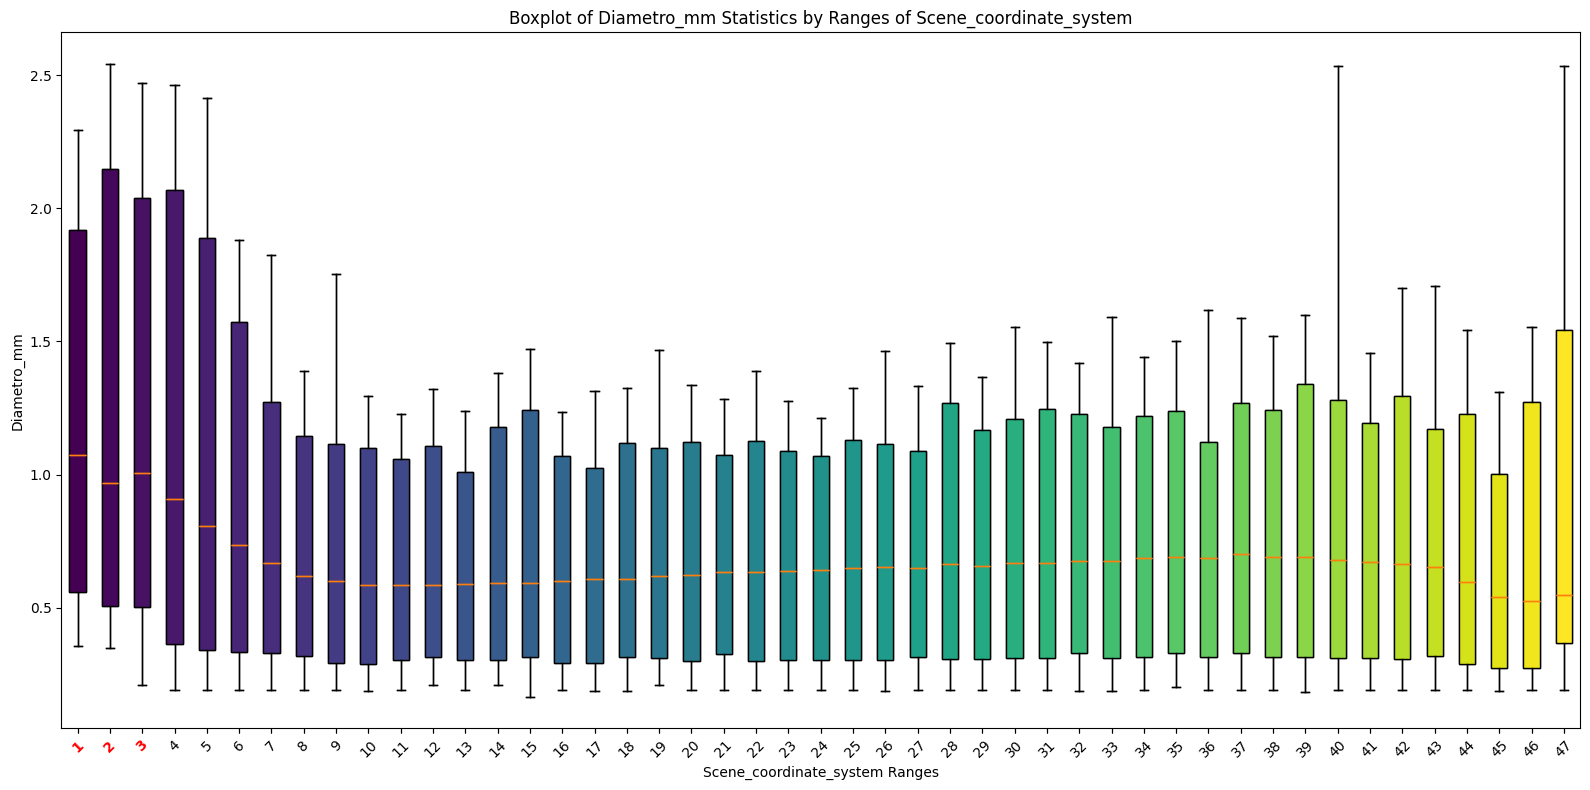

In [83]:
# Create bins for grouping 'Scene_coordinate_system' into ranges of 5
bins = np.arange(count_table['Scene_coordinate_system'].min(), 
                 count_table['Scene_coordinate_system'].max() + 2, 
                 2)

# Assign each 'Scene_coordinate_system' to a bin range for each scene
count_table['Group'] = pd.cut(count_table['Scene_coordinate_system'], bins=np.arange(count_table['Scene_coordinate_system'].min(), 
                 count_table['Scene_coordinate_system'].max() + 1, 
                 1), right=False)

# Prepare data for the boxplot
boxplot_data = []

# Loop through each group and collect min, max, and average for boxplot
for group in count_table['Group'].unique():
    group_data = count_table[count_table['Group'] == group]
    boxplot_data.append(group_data[['Min_Diametro_mm', 'Max_Diametro_mm', 'Diametro_mm']].values.flatten())

# Plot the boxplot
plt.figure(figsize=(16, 8))
plt.boxplot(boxplot_data, patch_artist=True, showfliers=True)

# Customize X-axis with group ranges
group_labels = [f"{interval.left:.2f}-{interval.right:.2f}" for interval in count_table['Group'].cat.categories]
plt.xticks(ticks=range(1, len(group_labels) + 1), labels=group_labels, rotation=45)

# Add labels and title
plt.xlabel('Scene_coordinate_system Ranges')
plt.ylabel('Diametro_mm')
plt.title('Boxplot of Diametro_mm Statistics by Ranges of Scene_coordinate_system')

# Add color to each boxplot
colors = plt.cm.viridis(np.linspace(0, 1, len(boxplot_data)))
for patch, color in zip(plt.boxplot(boxplot_data, patch_artist=True)['boxes'], colors):
    patch.set_facecolor(color)

# Highlight the top 3 groups with the highest average Diametro_mm
top3_groups = count_table.groupby('Group')['Diametro_mm'].mean().nlargest(3).index
for i, group in enumerate(count_table['Group'].cat.categories):
    if group in top3_groups:
        plt.gca().get_xticklabels()[i].set_color('red')
        plt.gca().get_xticklabels()[i].set_fontweight('bold')

# Display the plot
plt.tight_layout()
plt.show()


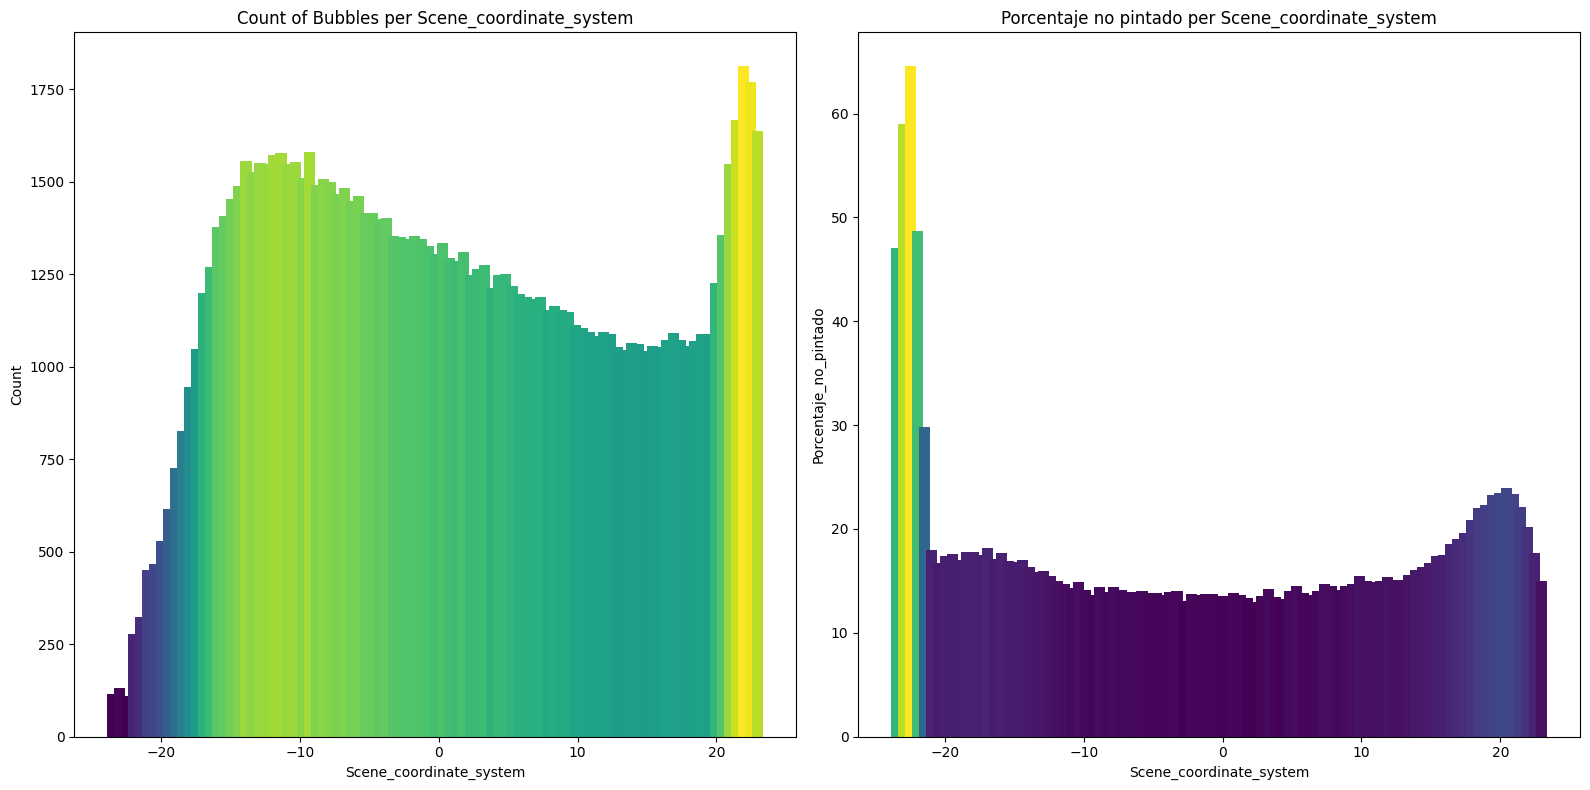

In [69]:
# Define a function to determine the color based on the count value using a gradient
def get_color(value, min_value, max_value):
    # Normalize the value to be between 0 and 1
    normalized_value = (value - min_value) / (max_value - min_value)
    # Convert the normalized value to a color using a colormap
    colormap = plt.cm.viridis
    return colormap(normalized_value)

# Get the minimum and maximum values of the 'Count' column
min_count = count_table['Count'].min()
max_count = count_table['Count'].max()

# Apply the color function to each value in the 'Count' column
colors_count = count_table['Count'].apply(lambda x: get_color(x, min_count, max_count))

# Get the minimum and maximum values of the 'Porcentaje_no_pintado' column
min_porcentaje = count_table['Porcentaje_no_pintado'].min()
max_porcentaje = count_table['Porcentaje_no_pintado'].max()

# Apply the color function to each value in the 'Porcentaje_no_pintado' column
colors_porcentaje = count_table['Porcentaje_no_pintado'].apply(lambda x: get_color(x, min_porcentaje, max_porcentaje))
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Plot the count data
axs[0].bar(count_table['Scene_coordinate_system'], count_table['Count'], color=colors_count)
axs[0].set_xlabel('Scene_coordinate_system')
axs[0].set_ylabel('Count')
axs[0].set_title('Count of Bubbles per Scene_coordinate_system')

# Plot the porcentaje no pintado data
axs[1].bar(count_table['Scene_coordinate_system'], count_table['Porcentaje_no_pintado'], color=colors_porcentaje)
axs[1].set_xlabel('Scene_coordinate_system')
axs[1].set_ylabel('Porcentaje_no_pintado')
axs[1].set_title('Porcentaje no pintado per Scene_coordinate_system')

# Adjust layout
plt.tight_layout()
plt.show()
